In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn import metrics
import seaborn as sns
import os
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
import matplotlib as mpl
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import joblib
from sklearn.preprocessing import StandardScaler

In [2]:
data = pd.read_csv("Dataset_ATS_v2.csv")

In [3]:
# Binary encoding
# Binary categorical variables were encoded using 0/1 mapping.
data["gender"] = data["gender"].map({"Female": 0, "Male": 1})
data["Dependents"] = data["Dependents"].map({"No": 0, "Yes": 1})
data["PhoneService"] = data["PhoneService"].map({"No": 0, "Yes": 1})
data["MultipleLines"] = data["MultipleLines"].map({"No": 0, "Yes": 1})
data["InternetService"] = data["InternetService"].map({
    "DSL": 0,
    "Fiber optic": 1
})
data["Churn"] = data["Churn"].map({"No": 0, "Yes": 1})

In [4]:
# Label encoding
# Label encoding was applied to ordinal categorical variables where a natural order exists.
contract_map = {
    "Month-to-month": 0,
    "One year": 1,
    "Two year": 2
}
data["Contract"] = data["Contract"].map(contract_map)

print("\nThe data after encoding:\n")
print(data)


The data after encoding:

      gender  SeniorCitizen  Dependents  tenure  PhoneService  MultipleLines  \
0          0              0           0       1             0              0   
1          1              0           0      41             1              0   
2          0              0           1      52             1              0   
3          0              0           0       1             1              0   
4          1              0           0      67             1              0   
...      ...            ...         ...     ...           ...            ...   
7038       1              0           0       1             1              1   
7039       0              0           1      23             1              1   
7040       1              0           1      12             1              0   
7041       1              1           0      12             1              1   
7042       1              0           0      26             1              0   

      Intern

In [5]:
# Remove target variable before clustering
X = data.drop(columns=["Churn"])

In [6]:
# ==================== scaling =========================
scaler = MinMaxScaler()
# normalises all features to the [0,1] range
X_scaled = pd.DataFrame(
    scaler.fit_transform(X),
    columns=X.columns,
    index=X.index
)

print("\nScaled data preview:")
print(X_scaled.head())



Scaled data preview:
   gender  SeniorCitizen  Dependents    tenure  PhoneService  MultipleLines  \
0     0.0            0.0         0.0  0.013889           0.0            0.0   
1     1.0            0.0         0.0  0.569444           1.0            0.0   
2     0.0            0.0         1.0  0.722222           1.0            0.0   
3     0.0            0.0         0.0  0.013889           1.0            0.0   
4     1.0            0.0         0.0  0.930556           1.0            0.0   

   InternetService  Contract  MonthlyCharges  
0              0.0       0.0        0.069307  
1              0.0       0.5        0.069307  
2              0.0       0.0        0.009901  
3              0.0       0.5        0.574257  
4              1.0       0.0        0.326733  


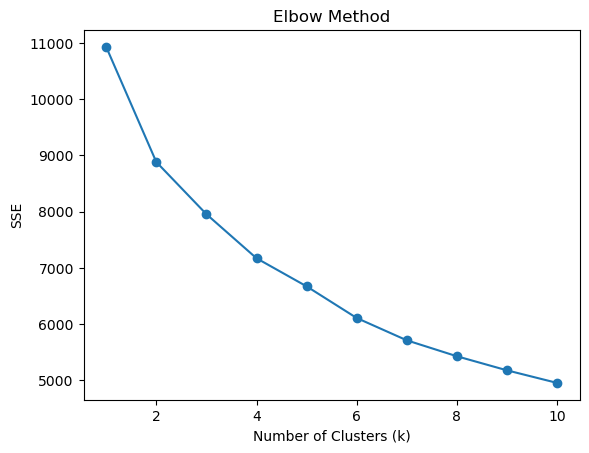

In [7]:
# ==================== elbow method =========================
sse = []
k_range = range(1,11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10, max_iter=300)
    kmeans.fit(X_scaled)
    sse.append(kmeans.inertia_)
    
plt.plot(k_range, sse, marker="o")
plt.title("Elbow Method")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("SSE")
# I forgot to save figures during video recording. so I added code to export the Elbow plot now
plt.savefig("Elbow_plot.png")
plt.show()

In [8]:
# use silhouette score to check optimal number 
silhouette_scores = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10, max_iter=300)
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    silhouette_scores.append(score)
    print(f"k={k}, silhouette score={score:.4f}")

k=2, silhouette score=0.1907
k=3, silhouette score=0.1690
k=4, silhouette score=0.1822
k=5, silhouette score=0.1958
k=6, silhouette score=0.2088
k=7, silhouette score=0.2110
k=8, silhouette score=0.1976
k=9, silhouette score=0.2179
k=10, silhouette score=0.2376


In [9]:
# KMeans clustering
optimal_k = 4
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
labels = kmeans.fit_predict(X_scaled)

In [10]:
# save our trained K-Means model into a file
joblib.dump(kmeans, "kmeans_model.pkl")
print("KMeans model saved as kmeans_model.pkl")

KMeans model saved as kmeans_model.pkl


In [11]:
# ======================== Add cluster labels =========================
data["Cluster"] = labels
print("\nCluster counts:")
print(pd.Series(labels).value_counts().sort_index())


Cluster counts:
0    1507
1    1796
2    1938
3    1802
dtype: int64



PCA 2D explained variance ratio:
[0.21831619 0.16141981]
Total explained variance (2 components): 0.37973600298156784


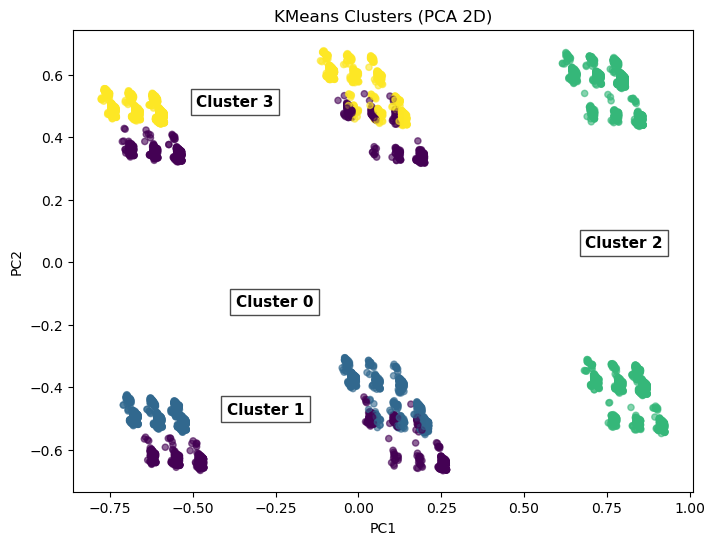

In [12]:
# ======================== PCA for Visualisation =========================
pca_2d = PCA(n_components=2, random_state=42)
X_2d = pca_2d.fit_transform(X_scaled)

print("\nPCA 2D explained variance ratio:")
print(pca_2d.explained_variance_ratio_)
print("Total explained variance (2 components):", pca_2d.explained_variance_ratio_.sum())

plt.figure(figsize=(8, 6))
plt.scatter(X_2d[:, 0], X_2d[:, 1], c=labels, cmap="viridis", s=20, alpha=0.6)

for i in np.unique(labels):
    x_center = X_2d[labels == i, 0].mean()
    y_center = X_2d[labels == i, 1].mean()
    plt.text(
        x_center, y_center, f"Cluster {i}",
        fontsize=11, fontweight="bold",
        ha="center", va="center",
        bbox=dict(facecolor="white", alpha=0.7, edgecolor="black")
    )
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("KMeans Clusters (PCA 2D)")
# I forgot to save figures during video recording. so I added code to export the PCA plot now
plt.savefig("PCA_plot.png")
plt.show()


In [13]:
# ======================== Cluster Profile =========================
data["Cluster"] = labels
# numeric profile
cluster_profile = data.groupby("Cluster").mean()
print("\nCluster profile:\n")
print(cluster_profile.T)
# I forgot to save figures during video recording. so I added code to export the Cluster Profile csv now
cluster_profile.to_csv("churn_profile.csv")


Cluster profile:

Cluster                  0          1          2          3
gender            0.513603   1.000000   0.508256   0.000000
SeniorCitizen     0.043132   0.207127   0.164603   0.214206
Dependents        1.000000   0.000000   0.311146   0.000000
tenure           38.134705  29.762249  32.794118  29.696448
PhoneService      0.893165   0.899220   0.912797   0.905105
MultipleLines     0.197744   0.202116   1.000000   0.206437
InternetService   0.244194   0.240535   1.000000   0.198668
Contract          0.738553   0.752784   0.553148   0.735849
MonthlyCharges   59.476443  66.081292  64.856553  67.753052
Churn             0.154612   0.309020   0.254386   0.326304



Churn rate by cluster:

Cluster
0    0.154612
1    0.309020
2    0.254386
3    0.326304
Name: Churn, dtype: float64


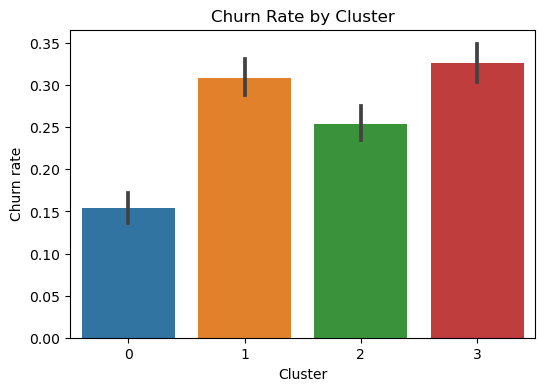

In [14]:
# ======================== Churn rate =========================
churn_rate = data.groupby("Cluster")["Churn"].mean()
print("\nChurn rate by cluster:\n")
print(churn_rate)

plt.figure(figsize=(6, 4))
sns.barplot(x="Cluster", y="Churn", data=data)
plt.title("Churn Rate by Cluster")
plt.xlabel("Cluster")
plt.ylabel("Churn rate")
# I forgot to save figures during video recording. so I added code to export the Churn Rate plot now
plt.savefig("Churn_Rate__by_Cluster_plot.png")
plt.show()

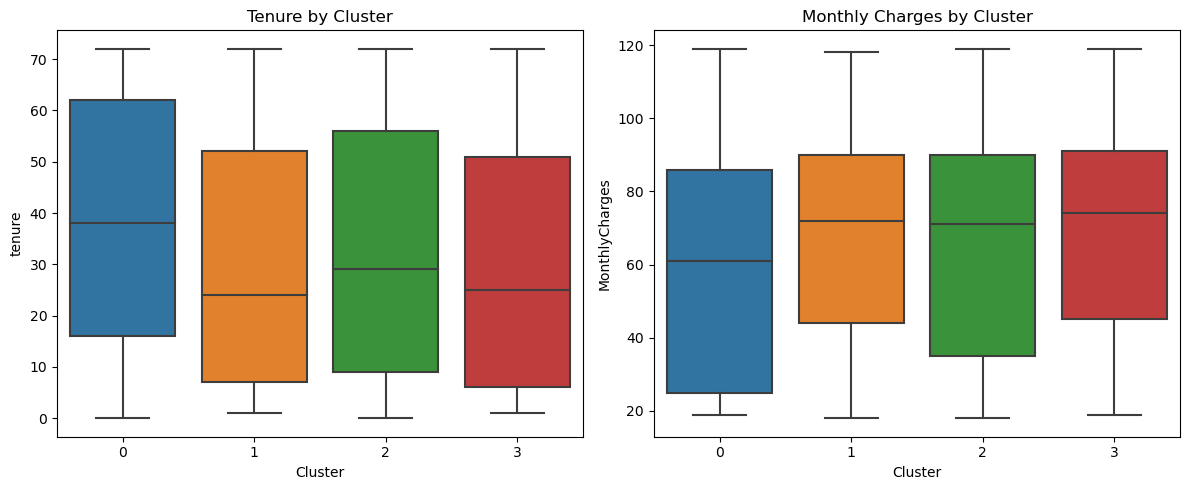

In [15]:
# ======================== Key Variable Boxplots =========================
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.boxplot(x="Cluster", y="tenure", data=data)
plt.title("Tenure by Cluster")

plt.subplot(1, 2, 2)
sns.boxplot(x="Cluster", y="MonthlyCharges", data=data)
plt.title("Monthly Charges by Cluster")

plt.tight_layout()

# I forgot to save figures during video recording. so I added code to export the plots now
plt.savefig("Key_Variables__by_Cluster_plot.png")
plt.show()